In [14]:
import pandas
import re

df = pandas.read_csv("data.csv")

# Drop the team numbers as they're only needed for training, not data gen
team_col_pattern = re.compile(r"^alliance_\d+_(captain|pick_2|pick_3)$")

df = df.drop(columns=[col for col in df.columns if team_col_pattern.match(col)])
df.head()

,year,event_key,winning_alliance,alliance_1_captain_epa,alliance_1_captain_epa_norm,alliance_1_captain_rp_1,alliance_1_captain_rp_2,alliance_1_pick_2_epa,alliance_1_pick_2_epa_norm,alliance_1_pick_2_rp_1,...,alliance_8_captain_rp_1,alliance_8_captain_rp_2,alliance_8_pick_2_epa,alliance_8_pick_2_epa_norm,alliance_8_pick_2_rp_1,alliance_8_pick_2_rp_2,alliance_8_pick_3_epa,alliance_8_pick_3_epa_norm,alliance_8_pick_3_rp_1,alliance_8_pick_3_rp_2
0,2023,2023alhu,1,1797.0,1720.0,0.5350,0.3892,1848.0,1778.0,0.5809,...,0.3786,0.3860,1636.0,1583.0,0.0471,0.0464,1656.0,1596.0,0.2618,0.2983
1,2023,2023arc,6,2001.0,1950.0,0.9105,0.5891,1945.0,1887.0,0.8864,...,0.3451,0.2404,1847.0,1777.0,0.3755,0.5433,1810.0,1735.0,0.7433,0.3920
2,2023,2023arli,2,1722.0,1637.0,0.0429,0.5166,1711.0,1631.0,0.1905,...,-0.1566,0.2616,1501.0,1493.0,-0.0657,0.3068,1541.0,1522.0,-0.0560,0.4677
3,2023,2023ausc,1,1784.0,1706.0,0.4411,0.5166,1641.0,1587.0,-0.0734,...,-0.1653,0.1012,1443.0,1444.0,-0.1580,0.3675,1485.0,1481.0,-0.0817,0.1358
4,2023,2023azgl,1,1774.0,1694.0,0.3061,0.3336,1651.0,1593.0,0.3131,...,-0.1031,0.3127,1503.0,1494.0,-0.0017,0.2122,1559.0,1534.0,-0.0716,0.3512


In [3]:
# Engineer values
# Compute per-alliance metric averages (e.g. epa, rp_1, rp_2) across
# captain, pick_2, pick_3 when all three metric columns are present.
import re
pattern = re.compile(r'^(alliance_\d+)_(captain|pick_2|pick_3)(?:_(.+))?$')
groups = {}
for col in df.columns:
    m = pattern.match(col)
    if not m:
        continue
    alliance_prefix = m.group(1)
    metric = m.group(3)  # e.g. 'epa', 'epa_norm', 'rp_1', etc.
    if metric is None:
        continue
    key = (alliance_prefix, metric)
    groups.setdefault(key, []).append(col)

for (alliance_prefix, metric), cols in groups.items():
    required = [f"{alliance_prefix}_captain_{metric}", f"{alliance_prefix}_pick_2_{metric}", f"{alliance_prefix}_pick_3_{metric}"]
    if all(c in cols for c in required):
        out_col = f"{alliance_prefix}_{metric}_avg"
        df[out_col] = df[required].mean(axis=1)

df.head()

/tmp/ipykernel_1207017/3742565640.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df[required].mean(axis=1)
/tmp/ipykernel_1207017/3742565640.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df[required].mean(axis=1)
/tmp/ipykernel_1207017/3742565640.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented

,year,event_key,winning_alliance,alliance_1_captain_epa,alliance_1_captain_epa_norm,alliance_1_captain_rp_1,alliance_1_captain_rp_2,alliance_1_pick_2_epa,alliance_1_pick_2_epa_norm,alliance_1_pick_2_rp_1,...,alliance_6_rp_1_avg,alliance_6_rp_2_avg,alliance_7_epa_avg,alliance_7_epa_norm_avg,alliance_7_rp_1_avg,alliance_7_rp_2_avg,alliance_8_epa_avg,alliance_8_epa_norm_avg,alliance_8_rp_1_avg,alliance_8_rp_2_avg
0,2023,2023alhu,1,1797.0,1720.0,0.5350,0.3892,1848.0,1778.0,0.5809,...,0.183800,0.288400,1571.000000,1541.000000,0.029867,0.279033,1661.000000,1599.000000,0.229167,0.243567
1,2023,2023arc,6,2001.0,1950.0,0.9105,0.5891,1945.0,1887.0,0.8864,...,0.422233,0.352667,1839.333333,1768.000000,0.575300,0.493867,1807.333333,1731.333333,0.487967,0.391900
2,2023,2023arli,2,1722.0,1637.0,0.0429,0.5166,1711.0,1631.0,0.1905,...,-0.073900,0.220800,1489.666667,1481.666667,-0.127433,0.277933,1510.333333,1499.666667,-0.092767,0.345367
3,2023,2023ausc,1,1784.0,1706.0,0.4411,0.5166,1641.0,1587.0,-0.0734,...,-0.125667,0.143400,1467.666667,1466.000000,-0.063900,0.094667,1467.000000,1465.333333,-0.135000,0.201500
4,2023,2023azgl,1,1774.0,1694.0,0.3061,0.3336,1651.0,1593.0,0.3131,...,-0.035833,0.175700,1532.666667,1515.333333,-0.037067,0.146733,1523.666667,1509.000000,-0.058800,0.292033


In [21]:
# Test whether average alliance EPA is correlated with winning
from scipy import stats

# Build one row per alliance, prefer pre-computed alliance EPA averages if present.
alliance_frames = []
for alliance_num in range(1, 9):
    avg_col = f"alliance_{alliance_num}_epa_avg"
    if avg_col in df.columns:
        alliance_avg = df[avg_col]
    else:
        epa_cols = [
            f"alliance_{alliance_num}_captain_epa",
            f"alliance_{alliance_num}_pick_2_epa",
            f"alliance_{alliance_num}_pick_3_epa",
        ]
        alliance_avg = df[epa_cols].mean(axis=1)

    alliance_win = (df["winning_alliance"] == alliance_num).astype(int)
    alliance_frame = pandas.DataFrame({"avg_epa": alliance_avg, "win": alliance_win})
    alliance_frames.append(alliance_frame.dropna(subset=["avg_epa"]))

analysis_df = pandas.concat(alliance_frames, ignore_index=True)

# Point-biserial correlation is the Pearson correlation between a numeric value and a binary label.
r, p_value = stats.pointbiserialr(analysis_df["win"], analysis_df["avg_epa"])

winning_mean = analysis_df.loc[analysis_df["win"] == 1, "avg_epa"].mean()
losing_mean = analysis_df.loc[analysis_df["win"] == 0, "avg_epa"].mean()

r_squared = r ** 2
mean_diff = winning_mean - losing_mean

print(f"Rows used: {len(analysis_df)}")
print(f"Mean avg EPA when winning: {winning_mean:.2f}")
print(f"Mean avg EPA when losing: {losing_mean:.2f}")
print(f"Mean difference (winning - losing): {mean_diff:.2f} EPA")
print(f"Point-biserial correlation r: {r:.4f}")
print(f"r^2 (variance explained): {r_squared:.4f} ({r_squared*100:.1f}%)")
print(f"p-value: {p_value:.3e}")
print("Statistically significant at alpha = 0.05:" , p_value < 0.05)


Rows used: 6144
Mean avg EPA when winning: 1673.86
Mean avg EPA when losing: 1559.16
Mean difference (winning - losing): 114.69 EPA
Point-biserial correlation r: 0.3801
r^2 (variance explained): 0.1445 (14.5%)
p-value: 1.837e-210
Statistically significant at alpha = 0.05: True


/tmp/ipykernel_244544/1573980415.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


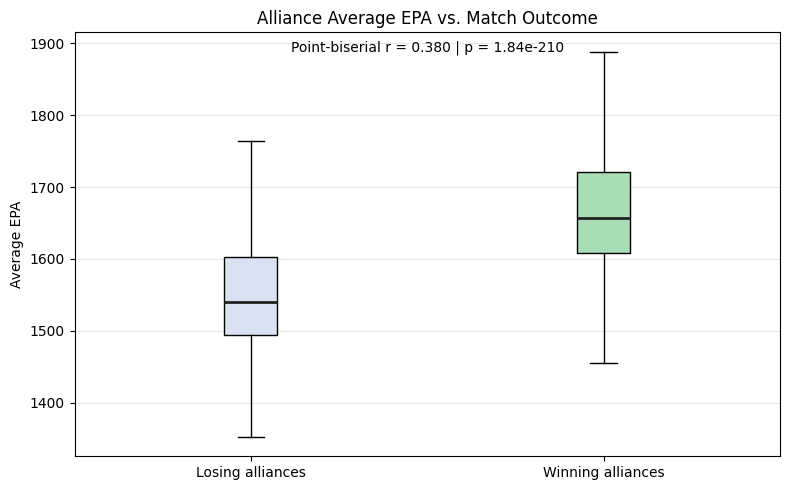

In [17]:
import matplotlib.pyplot as plt

win_vals = analysis_df.loc[analysis_df["win"] == 1, "avg_epa"]
lose_vals = analysis_df.loc[analysis_df["win"] == 0, "avg_epa"]

fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    [lose_vals, win_vals],
    labels=["Losing alliances", "Winning alliances"],
    patch_artist=True,
    showfliers=False,
)

box["boxes"][0].set_facecolor("#d9e2f3")
box["boxes"][1].set_facecolor("#a8ddb5")
for median in box["medians"]:
    median.set_color("#222222")
    median.set_linewidth(2)

ax.set_title("Alliance Average EPA vs. Match Outcome")
ax.set_ylabel("Average EPA")
ax.text(
    0.5,
    0.98,
    f"Point-biserial r = {r:.3f} | p = {p_value:.2e}",
    transform=ax.transAxes,
    ha="center",
    va="top",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_244544/1000083482.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[0].boxplot([lose_vals, win_vals], labels=['Losing alliances', 'Winning alliances'], patch_artist=True, showfliers=False)


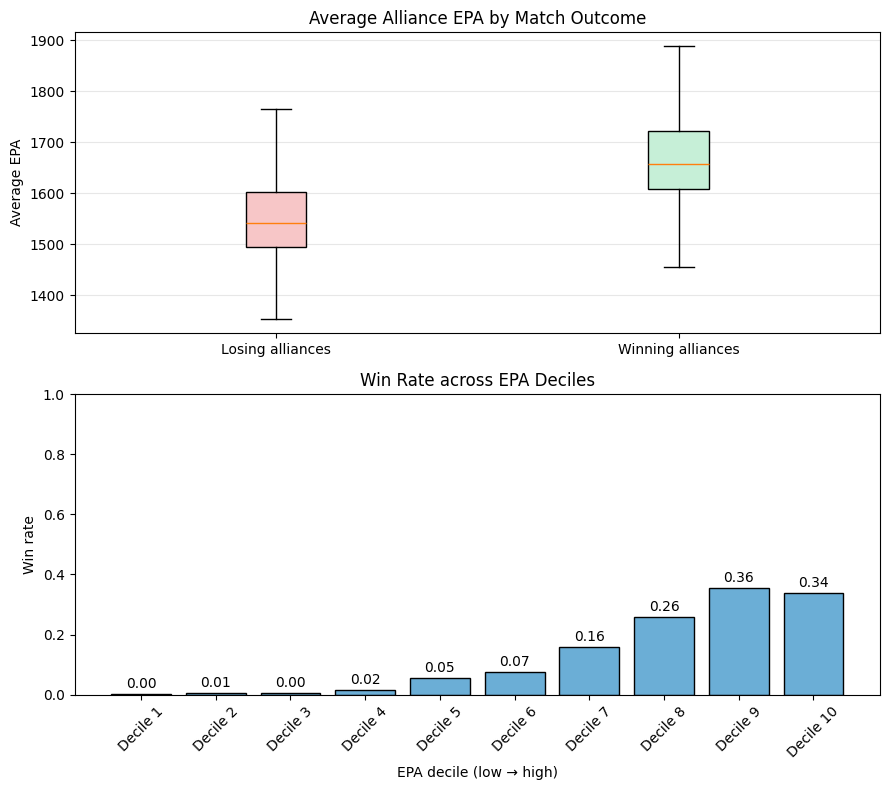

In [18]:
# Combined visualization: boxplot and EPA-decile win rate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# analysis_df is created earlier: one row per alliance with 'avg_epa' and binary 'win'
dfv = analysis_df.copy()
# create EPA deciles to show how win rate changes with EPA
dfv['epa_decile'] = pd.qcut(dfv['avg_epa'], 10, labels=False)
win_rate = dfv.groupby('epa_decile')['win'].mean()
counts = dfv.groupby('epa_decile')['win'].size()

fig, axes = plt.subplots(2, 1, figsize=(9, 8), gridspec_kw={'height_ratios': [1, 1]})

# Top: boxplot of avg EPA by win/loss
lose_vals = dfv.loc[dfv['win'] == 0, 'avg_epa']
win_vals = dfv.loc[dfv['win'] == 1, 'avg_epa']
box = axes[0].boxplot([lose_vals, win_vals], labels=['Losing alliances', 'Winning alliances'], patch_artist=True, showfliers=False)
box['boxes'][0].set_facecolor('#f7c6c7')
box['boxes'][1].set_facecolor('#c6efd7')
axes[0].set_ylabel('Average EPA')
axes[0].set_title('Average Alliance EPA by Match Outcome')
axes[0].grid(axis='y', alpha=0.3)

# Bottom: win rate by EPA decile
x = win_rate.index.astype(int)
axes[1].bar(x, win_rate.values, color='#6baed6', edgecolor='k')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Decile {i+1}" for i in x], rotation=45)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('EPA decile (low → high)')
axes[1].set_ylabel('Win rate')
axes[1].set_title('Win Rate across EPA Deciles')
for i, v in enumerate(win_rate.values):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()
